# 2D Poisson FEM — 最小二乘 QUBO (单次求解, 无分块)
## $\min_x \|K_{ii} x - r\|^2$  →  $Q = K_{ii}^2 \otimes (s s^T) + 2\cdot\text{diag}(M^T K_{ii}(K_{ii}c - r))$
不分块, 全局装配 → 一次 CIM 求解

In [1]:
import numpy as np, matplotlib.pyplot as plt, time, warnings, json, os
warnings.filterwarnings('ignore')
import kaiwu as kw
kw.common.CheckpointManager.save_dir = '/tmp'

Lx, Ly = 3.0, 2.0
Nx, Ny = 8, 8          # 粗网格, 单次求解
BIT_WIDTH = 8
OUTPUT_DIR = 'D:/QPDE/pde_single_outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f'网格: {Nx}×{Ny}, 位宽: {BIT_WIDTH}')

网格: 8×8, 位宽: 8


In [2]:
# ===== 网格 =====
x = np.linspace(0, Lx, Nx); y = np.linspace(0, Ly, Ny)
X, Y = np.meshgrid(x, y, indexing='ij')
nodes = np.column_stack([X.ravel(), Y.ravel()])
n_nodes = Nx * Ny
boundary = (X.ravel()==0) | (X.ravel()==Lx) | (Y.ravel()==0) | (Y.ravel()==Ly)
internal = ~boundary
n_i = internal.sum()
print(f'总节点: {n_nodes}, 内部: {n_i}, QUBO变量: {n_i * BIT_WIDTH}')

总节点: 64, 内部: 36, QUBO变量: 288


In [3]:
# ===== 解析解 & 源项 =====
def u_exact(x, y):
    return x * y * np.cos(2*np.pi*x/3.0)

def source_term(x, y):
    u_xx = -(2*np.pi/3.0)**2 * x * y * np.cos(2*np.pi*x/3.0) - (4*np.pi/3.0) * y * np.sin(2*np.pi*x/3.0)
    return -(u_xx + 0.0)

u_exact_all = np.array([u_exact(xi, yi) for xi, yi in nodes])
print(f'精确解: [{u_exact_all.min():.4f}, {u_exact_all.max():.4f}]')

精确解: [-3.0890, 6.0000]


In [4]:
# ===== FEM 装配 (5-point FD) =====
hx = Lx/(Nx-1); hy = Ly/(Ny-1)
K = np.zeros((n_nodes, n_nodes)); F = np.zeros(n_nodes)
for i in range(1, Nx-1):
    for j in range(1, Ny-1):
        k = i*Ny + j
        K[k,k] = 2/hx**2 + 2/hy**2
        K[k, k-1] = K[k, k+1] = -1/hy**2
        K[k, k-Ny] = K[k, k+Ny] = -1/hx**2
        F[k] = source_term(nodes[k,0], nodes[k,1])
print(f'K: {K.shape}, cond(K)={np.linalg.cond(K):.2e}')

K: (64, 64), cond(K)=inf


In [5]:
# ===== Dirichlet BC 归约 =====
idx_map = -np.ones(n_nodes, dtype=int)
idx_map[internal] = np.arange(n_i)
K_ii = np.zeros((n_i, n_i)); rhs = np.zeros(n_i)
for gi in np.where(internal)[0]:
    ki = idx_map[gi]; K_ii[ki, ki] = K[gi, gi]; rhs[ki] = F[gi]
    for gj in [gi-1, gi+1, gi-Ny, gi+Ny]:
        if 0 <= gj < n_nodes:
            if internal[gj]: K_ii[ki, idx_map[gj]] = K[gi, gj]
            else: rhs[ki] -= K[gi, gj] * u_exact(nodes[gj,0], nodes[gj,1])
u_ref = np.linalg.solve(K_ii, rhs)
print(f'经典解: [{u_ref.min():.4f}, {u_ref.max():.4f}]')

经典解: [-2.7478, 2.7176]


In [6]:
# ===== 编码边界 =====
margin = 0.5; rng = max(u_ref.max()-u_ref.min(), 0.1)
lb = u_ref.min() - margin*rng; ub = u_ref.max() + margin*rng
print(f'编码界: [{lb:.4f}, {ub:.4f}]')

编码界: [-5.4805, 5.4504]


In [7]:
# ===== LS-QUBO 构建 (Kronecker) =====
def build_ls_qubo(K_ii, rhs, bw, lb, ub):
    n = K_ii.shape[0]; nvar = n*bw
    scale = (ub-lb)/(2**bw-1)
    s = scale * np.array([2**k for k in range(bw)]); ssT = np.outer(s,s)
    c = lb * np.ones(n); d = K_ii@c - rhs; Ad = K_ii@d; K2 = K_ii@K_ii
    Q = np.zeros((nvar, nvar))
    for i in range(n):
        for j in range(i, n):
            if abs(K2[i,j]) < 1e-15: continue
            ri, rj = i*bw, j*bw; blk = K2[i,j]*ssT
            Q[ri:ri+bw, rj:rj+bw] += blk
            if i != j: Q[rj:rj+bw, ri:ri+bw] += blk.T
    for i in range(n): Q[i*bw:(i+1)*bw, i*bw:(i+1)*bw] += np.diag(2*Ad[i]*s)
    return Q.astype(np.float32), nvar, scale

def decode(z_best, n, bw, scale, lb):
    M = np.zeros((n, n*bw)); s = scale*np.array([2**k for k in range(bw)])
    for i in range(n): M[i, i*bw:(i+1)*bw] = s
    return M@z_best + lb

Q_float, nvar, scale = build_ls_qubo(K_ii, rhs, BIT_WIDTH, lb, ub)
Q_qubo = kw.qubo.adjust_qubo_matrix_precision(Q_float)
print(f'QUBO: {nvar}x{nvar}, 值: [{Q_qubo.min():.0f}, {Q_qubo.max():.0f}]')

QUBO: 288x288, 值: [-1016, 1188]


In [8]:
# ===== CIM 提交 =====
ising_mat, ising_bias = kw.conversion.qubo_matrix_to_ising_matrix(Q_qubo)
vars_ = [f'x[{i}]' for i in range(ising_mat.shape[0])]
model = kw.ising.IsingModel(variables=vars_, ising_matrix=ising_mat, bias=ising_bias)
opt = kw.cim.CIMOptimizer(task_name='pde_ls_single', task_mode='quota')
t0 = time.time()
opt.solve(model.get_matrix())
print(f'已提交, Ising: {ising_mat.shape}')

[2026-05-20 21:24:40] [INFO    ] [kaiwu.cim._optimizer_adapter:7] - Task submit successfully, waiting for data validation. Task name: pde_ls_single
已提交, Ising: (289, 289)


In [9]:
# ===== CIM 取回 + 解码 =====
sol = opt.solve(model.get_matrix())
dt = time.time()-t0; print(f'返回: {sol.shape}, 耗时: {dt:.1f}s')

sols_bin = (sol[:,:-1]*sol[:,-1:]+1)/2
energies = np.array([z@Q_qubo@z for z in sols_bin])
z_best = sols_bin[np.argmin(energies)]
u_quantum_i = decode(z_best, n_i, BIT_WIDTH, scale, lb)

u_quantum = np.zeros(n_nodes); u_quantum[internal] = u_quantum_i
for gi in np.where(boundary)[0]: u_quantum[gi] = u_exact(nodes[gi,0], nodes[gi,1])

rmse_ref = np.sqrt(np.mean((u_quantum_i - u_ref)**2))
rmse_ex  = np.sqrt(np.mean((u_quantum - u_exact_all)**2))
print(f'最优能量: {energies.min():.1f}')
print(f'RMSE vs 经典: {rmse_ref:.6e}, RMSE vs 精确解: {rmse_ex:.6e}')

[2026-05-20 21:25:57] [INFO    ] [kaiwu.cim._optimizer_adapter:2] - Task completed: pde_ls_single
返回: (10, 289), 耗时: 78.7s
最优能量: -1972.0
RMSE vs 经典: 2.703804e+00, RMSE vs 精确解: 1.996464e+00


In [10]:
# ===== 保存 =====
np.save(f'{OUTPUT_DIR}/u_quantum_ls.npy', u_quantum)
np.save(f'{OUTPUT_DIR}/u_ref_ls.npy', u_ref)
np.save(f'{OUTPUT_DIR}/nodes_ls.npy', nodes)
res = {'method':'ls_single','grid':f'{Nx}x{Ny}','n_internal':int(n_i),
       'qubo_size':int(nvar),'time_sec':dt,
       'rmse_vs_ref':float(rmse_ref),'rmse_vs_exact':float(rmse_ex),
       'best_energy':float(energies.min())}
with open(f'{OUTPUT_DIR}/result_ls.json','w') as f: json.dump(res, f, indent=2)
print('结果已保存')

结果已保存


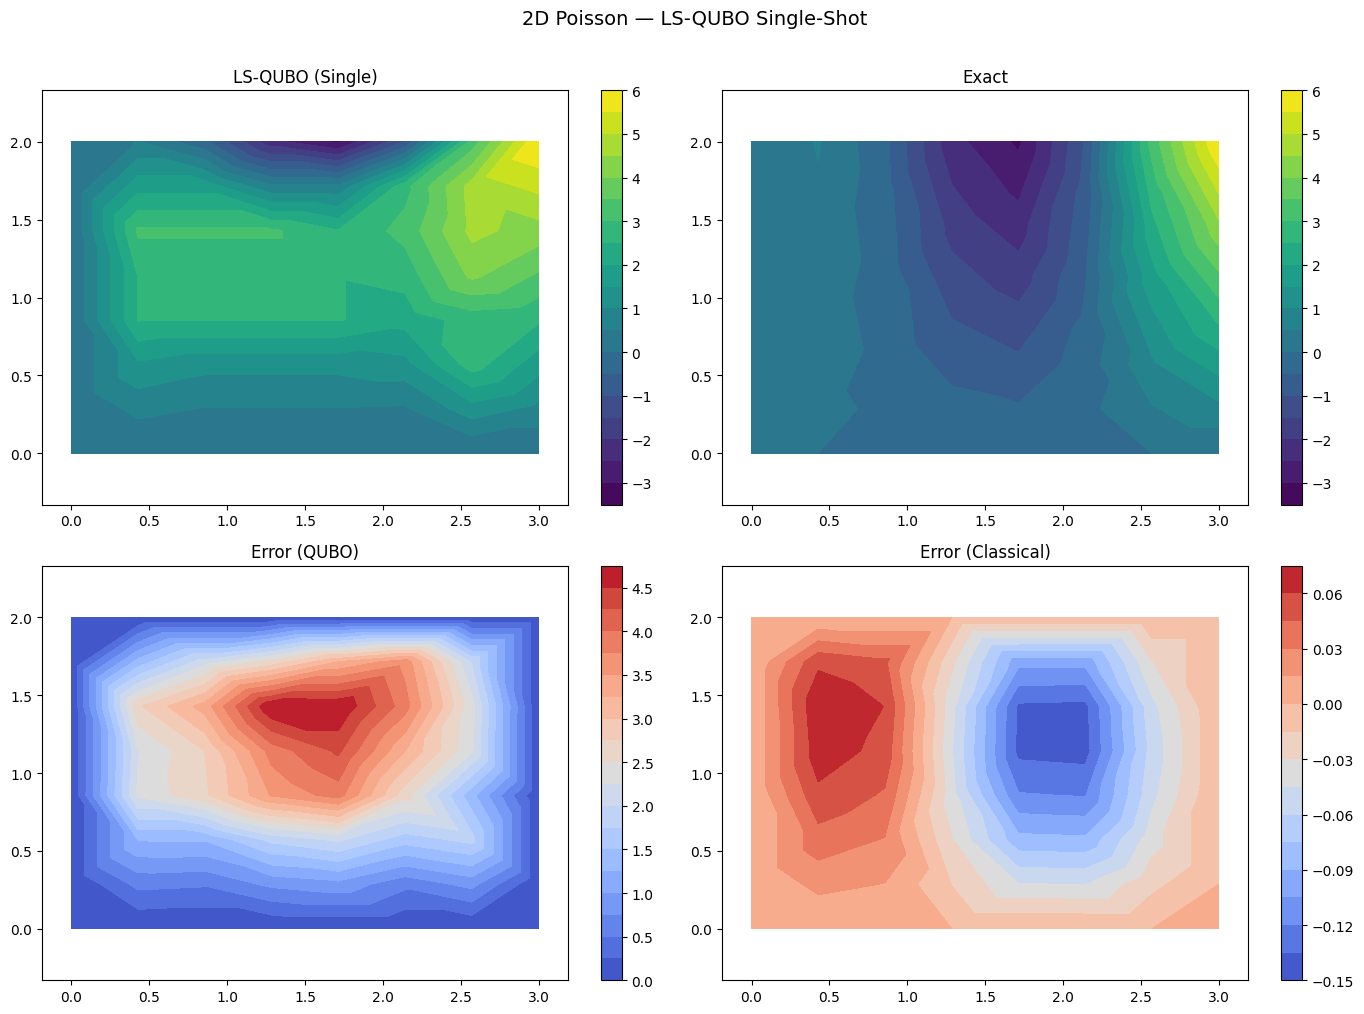

In [14]:
u_ref_all = np.zeros(n_nodes)
u_ref_all[internal] = u_ref
for gi in np.where(boundary)[0]: u_ref_all[gi] = u_exact(nodes[gi,0], nodes[gi,1])
# ===== 可视化 =====
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, data, title in [(axes[0,0], u_quantum, 'LS-QUBO (Single)'),
                          (axes[0,1], u_exact_all, 'Exact'),
                          (axes[1,0], u_quantum-u_exact_all, 'Error (QUBO)'),
                          (axes[1,1], u_ref_all-u_exact_all, 'Error (Classical)')]:
    cmap = 'coolwarm' if 'Error' in title else 'viridis'
    im = ax.tricontourf(nodes[:,0], nodes[:,1], data, levels=20, cmap=cmap)
    ax.set_title(title); ax.axis('equal'); fig.colorbar(im, ax=ax)
fig.suptitle('2D Poisson — LS-QUBO Single-Shot', fontsize=14, y=1.01)
plt.tight_layout(); plt.savefig(f'{OUTPUT_DIR}/ls_single.png', dpi=150, bbox_inches='tight')
plt.show()